# QB Fantasy Projection Model
Per-game prediction of 6 QB outcomes:
passing_yards, passing_tds, interceptions, rushing_yards, rushing_tds, fumbles_lost_total

Pipeline:
  Phase 2  — Exploratory Data Analysis
  Phase 3  — Feature prep & pruning
  Phase 4  — Baselines
  Phase 5  — LightGBM (per-target, per-target Optuna search)
  Phase 6  — Evaluation & diagnostics
  Phase 7  — Feature importance / SHAP
  Phase 8  — XGBoost challenger
  Phase 9  — Ensemble / stacking

In [ ]:
import io
import sys
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")           # non-interactive backend — safe in both script and notebook
import matplotlib.pyplot as plt

def _show(fig_path):
    """Display a saved figure inline when running in Jupyter; silent no-op in script mode."""
    try:
        from IPython.display import display, Image as _IPImage
        display(_IPImage(str(fig_path)))
    except Exception:
        pass
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

warnings.filterwarnings("ignore")

try:
    buf = getattr(sys.stdout, "buffer", None)
    if buf is not None:
        sys.stdout = io.TextIOWrapper(buf, encoding="utf-8", errors="replace")
except Exception:
    pass

try:
    DATA_DIR = Path(__file__).resolve().parent
except NameError:
    DATA_DIR = Path.cwd()

MASTER_PATH = DATA_DIR / "data" / "master" / "nfl_master_dataset.parquet"
FIG_DIR     = DATA_DIR / "figures" / "qb_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = [
    "passing_yards",
    "passing_tds",
    "interceptions",
    "rushing_yards",
    "rushing_tds",
    "fumbles_lost_total",
]

TRAIN_START = 2006
TRAIN_END   = 2022   # train through 2022; 2023-2024 = val for more robust Optuna signal
VAL_START   = 2023
VAL_END     = 2024
TEST_YEAR   = 2025

In [ ]:
# --- Load and scope to QBs ---
print("Loading master dataset...")
master = pd.read_parquet(MASTER_PATH)
print(f"  Master shape: {master.shape}")

qb = master[
    (master["position"] == "QB") &
    (master["season"] >= TRAIN_START)
].copy()

print(f"  QB rows (2006-2025): {len(qb):,}")
print(f"  Seasons: {sorted(qb['season'].unique())}")
print(f"  Unique players: {qb['player_id'].nunique():,}")

## Phase 2 — Exploratory Data Analysis

In [ ]:
# =============================================================================
# 2.1  TARGET DISTRIBUTIONS
# =============================================================================

print("\n" + "="*60)
print("2.1  TARGET DISTRIBUTIONS")
print("="*60)

# Split sets for distribution analysis
train = qb[qb["season"] <= TRAIN_END].copy()
val   = qb[qb["season"].between(VAL_START, VAL_END)].copy()   # 2023-2024
test  = qb[qb["season"] == TEST_YEAR].copy()                  # 2025

print(f"\nSet sizes:  train={len(train):,}  val={len(val):,}  test={len(test):,}")
print()

# --- Summary statistics per target ---
stat_rows = []
for t in TARGETS:
    s = train[t].dropna()
    stat_rows.append({
        "target":   t,
        "n":        len(s),
        "mean":     s.mean(),
        "median":   s.median(),
        "std":      s.std(),
        "min":      s.min(),
        "max":      s.max(),
        "skewness": s.skew(),
        "kurtosis": s.kurtosis(),
        "pct_zero": (s == 0).mean() * 100,
        "pct_null": train[t].isna().mean() * 100,
    })

stats_df = pd.DataFrame(stat_rows).set_index("target")
print("Target summary statistics (train set 2006-2022):")
print(stats_df.to_string(float_format="{:.3f}".format))

In [ ]:
# --- Distribution plots: histogram + KDE + Q-Q per target ---
fig, axes = plt.subplots(len(TARGETS), 3, figsize=(18, 4 * len(TARGETS)))
fig.suptitle("QB Target Distributions (Train 2006-2022)", fontsize=14, fontweight="bold")

for i, t in enumerate(TARGETS):
    s = train[t].dropna()

    # Histogram + KDE
    ax1 = axes[i, 0]
    ax1.hist(s, bins=50, color="steelblue", alpha=0.7, edgecolor="none", density=True)
    s.plot.kde(ax=ax1, color="darkblue", linewidth=2)
    ax1.set_title(f"{t}\nmean={s.mean():.2f}  skew={s.skew():.2f}  zeros={((s==0).mean()*100):.0f}%")
    ax1.set_xlabel(t)
    ax1.set_ylabel("Density")

    # Log-scale histogram (reveals tail behaviour)
    ax2 = axes[i, 1]
    nonzero = s[s > 0]
    if len(nonzero) > 0:
        ax2.hist(np.log1p(nonzero), bins=50, color="coral", alpha=0.7, edgecolor="none", density=True)
        ax2.set_title(f"{t} — log1p(nonzero)")
        ax2.set_xlabel("log1p(value)")
        ax2.set_ylabel("Density")

    # Q-Q plot vs normal
    ax3 = axes[i, 2]
    stats.probplot(s, dist="norm", plot=ax3)
    ax3.set_title(f"{t} — Q-Q vs Normal")

plt.tight_layout()
out = FIG_DIR / "target_distributions.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.close()
print(f"\nSaved: {out}")

In [ ]:
# --- Zero-inflation detail ---
print("\nZero-inflation detail (train):")
for t in TARGETS:
    s = train[t].dropna()
    n_zero  = (s == 0).sum()
    n_one   = (s == 1).sum()
    n_two   = (s == 2).sum()
    n_three = (s >= 3).sum()
    print(f"  {t:<25}  0:{n_zero:5d} ({n_zero/len(s)*100:4.1f}%)  "
          f"1:{n_one:5d}  2:{n_two:4d}  3+:{n_three:4d}")

In [ ]:
# --- Distribution stability across eras ---
print("\nTarget means by era (train only):")
era_bins = [(2006,2012,"2006-12 no_snaps"), (2013,2015,"2013-15 no_ngs"), (2016,2022,"2016-22 full")]
header = f"  {'Target':<25}" + "".join(f"  {label:>20}" for _,_,label in era_bins)
print(header)
for t in TARGETS:
    row = f"  {t:<25}"
    for y1, y2, label in era_bins:
        sub = train[(train["season"] >= y1) & (train["season"] <= y2)][t].dropna()
        row += f"  {sub.mean():>8.3f} (n={len(sub):5d})"
    print(row)

In [ ]:
# --- Season trend: has the game changed? ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("QB Target Means by Season (train set)", fontsize=13, fontweight="bold")

for i, t in enumerate(TARGETS):
    by_yr = (
        train.groupby("season")[t]
        .agg(mean="mean", sem=lambda x: x.std() / np.sqrt(len(x)))
        .reset_index()
    )
    ax = axes[i]
    ax.plot(by_yr["season"], by_yr["mean"], marker="o", color="steelblue")
    ax.fill_between(
        by_yr["season"],
        by_yr["mean"] - by_yr["sem"],
        by_yr["mean"] + by_yr["sem"],
        alpha=0.2, color="steelblue"
    )
    ax.axvline(2013, color="orange", linestyle="--", linewidth=1, label="snaps avail")
    ax.axvline(2016, color="green",  linestyle="--", linewidth=1, label="NGS avail")
    ax.set_title(t)
    ax.set_xlabel("Season")
    ax.set_ylabel("Mean per game")
    ax.legend(fontsize=7)

plt.tight_layout()
out = FIG_DIR / "target_trend_by_season.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.close()
print(f"Saved: {out}")

In [ ]:
# =============================================================================
# 2.2  FEATURE DISTRIBUTIONS  (QB-relevant features only)
# =============================================================================

print("\n" + "="*60)
print("2.2  FEATURE NULL RATES (QB rows, train set)")
print("="*60)

# Define QB candidate features for passing_yards model
#
# Base = my full recommendation from feature audit.
# User overrides applied on top:
#   passing_yards      : all 4 windows (override: was L5+L20 only)
#   yards_per_attempt  : L5/L10/L20   (override: was L5/L20)
#   epa_per_dropback   : L5/L10/L20   (override: was L5/L20)
#   air_yards          : L5/L10/L20   (override: was L5/L20)
#   qb_pressure_rate   : L3/L10/L20   (override: was L5 only)
#   epa_per_opportunity: L5/L10/L20   (override: was L20 only)
#   NGS stats          : all 4 windows (override: was single windows each)
#   off_rb_receiving   : L5/L10/L20   (override: was drop all)
#   game_precip_mm     : keep          (override: was drop)
#   rest_days_opponent : keep          (override: was drop)
QB_FEATURES = [
    # --- Identity / context ---
    "depth_chart_rank",
    "age",
    "games_played_current_season",
    "week",

    # --- Rolling passing volume: all 4 windows (user override) ---
    *[f"passing_yards_L{w}" for w in [3, 5, 10, 20]],

    # --- Rolling passing rate stats ---
    # dropped: td_rate, int_rate (noisy proxies; EPA captures them)
    # dropped: qb_scramble_rate (captured by rushing_yards_L20)
    *[f"yards_per_attempt_L{w}"        for w in [5, 10, 20]],
    "completion_pct_L20",
    *[f"epa_per_dropback_L{w}"         for w in [5, 10, 20]],
    "qb_cpoe_L5", "qb_cpoe_L20",
    *[f"qb_air_yards_per_attempt_L{w}" for w in [5, 10, 20]],
    *[f"qb_pressure_rate_L{w}"         for w in [3, 10, 20]],
    *[f"epa_per_opportunity_L{w}"      for w in [5, 10, 20]],

    # --- Rushing: L20 only (dual-threat ID + passing-volume trade-off) ---
    "rushing_yards_L20",

    # --- NGS: all 4 windows (user override; NaN pre-2016 handled natively) ---
    *[f"ngs_avg_time_to_throw_L{w}"        for w in [3, 5, 10, 20]],
    *[f"ngs_avg_intended_air_yards_L{w}"   for w in [3, 5, 10, 20]],
    *[f"ngs_aggressiveness_L{w}"           for w in [3, 5, 10, 20]],
    *[f"ngs_completion_pct_above_exp_L{w}" for w in [3, 5, 10, 20]],

    # --- Own offense quality ---
    # dropped: off_rb_epa_per_carry, off_rb_yards_per_carry (run game ≠ pass yards)
    # dropped: off_wr_epa_per_target, off_wr_racr (collinear with WOPR/off_epa)
    # dropped: off_te_target_share (captured by off_te_epa_per_target)
    "off_epa_per_play_L5", "off_epa_per_play_L20",
    "off_pass_rate_L5",
    *[f"off_rb_receiving_yards_L{w}" for w in [5, 10, 20]],
    "off_wr_wopr_L5",
    "off_wr_adot_L5",
    "off_te_epa_per_target_L5",
    "off_te_yprr_L5",            # yards per route run — best single TE efficiency metric
    "off_te_route_run_rate_L5",  # TE scheme involvement in pass game

    # --- Opponent defense quality ---
    # dropped: opp_def_qb_td_rate (noisy proxy; EPA covers it)
    # dropped: opp_def_team_epa_per_rush (rush D quality irrelevant to passing yards)
    "opp_def_qb_qb_epa_per_attempt_L5", "opp_def_qb_qb_epa_per_attempt_L20",
    "opp_def_qb_qb_cpoe_L5",
    "opp_def_team_team_epa_per_pass_L5",

    # --- Game environment ---
    # dropped: is_turf, stadium_altitude
    "game_location",
    "is_dome",
    "game_temp",
    "game_wind",
    "game_precip_mm",
    "rest_days",
    "rest_days_opponent",
]

# Keep only columns that actually exist in the dataset
QB_FEATURES = [f for f in QB_FEATURES if f in qb.columns]
print(f"\nCandidate features: {len(QB_FEATURES)}")

# Null rates across eras
print(f"\n{'Feature':<50} {'all%':>6} {'2006-12%':>9} {'2013-15%':>9} {'2016-22%':>9}")
print("-" * 88)
era1 = train[train["season"] <= 2012]
era2 = train[(train["season"] >= 2013) & (train["season"] <= 2015)]
era3 = train[train["season"] >= 2016]

problem_features = []  # features null >70% in 2016-2022 era
for f in QB_FEATURES:
    n_all  = train[f].isna().mean() * 100
    n_e1   = era1[f].isna().mean()  * 100
    n_e2   = era2[f].isna().mean()  * 100
    n_e3   = era3[f].isna().mean()  * 100
    flag   = " <-- HIGH" if n_e3 > 70 else ""
    if n_e3 > 70:
        problem_features.append(f)
    if n_all > 5 or flag:   # only print non-trivial null rates
        print(f"  {f:<50} {n_all:>5.1f}% {n_e1:>8.1f}% {n_e2:>8.1f}% {n_e3:>8.1f}%{flag}")

if problem_features:
    print(f"\nFeatures >70% null in 2016-2022 era (candidates for removal): {problem_features}")
else:
    print("\nNo features >70% null in 2016-2022 era.")

In [ ]:
# =============================================================================
# 2.3  TARGET-FEATURE CORRELATIONS
# =============================================================================

print("\n" + "="*60)
print("2.3  TARGET-FEATURE CORRELATIONS (Spearman, train 2016-2022)")
print("="*60)

# Use full-feature era only for correlation analysis
train_full = train[train["season"] >= 2016].copy()

print("\nTop 15 features correlated with each target (Spearman |r|):")
top_features_per_target = {}
for t in TARGETS:
    corrs = {}
    y = train_full[t].dropna()
    for f in QB_FEATURES:
        col = train_full.loc[y.index, f]
        valid = col.notna() & y.notna()
        if valid.sum() < 100:
            continue
        r, _ = stats.spearmanr(col[valid], y[valid])
        if not np.isnan(r):
            corrs[f] = r
    top = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
    top_features_per_target[t] = [f for f, _ in top]
    print(f"\n  {t}:")
    for f, r in top:
        bar = "#" * int(abs(r) * 30)
        print(f"    {f:<50} r={r:+.3f}  {bar}")

In [ ]:
# --- Correlation heatmap: top features for passing_yards ---
top_py_feats = top_features_per_target.get("passing_yards", QB_FEATURES[:20])
corr_data = train_full[top_py_feats + ["passing_yards"]].dropna()
if len(corr_data) > 50:
    corr_matrix = corr_data.corr(method="spearman")
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
        center=0, square=True, linewidths=0.3, ax=ax,
        annot_kws={"size": 7}
    )
    ax.set_title("Spearman correlations — top passing_yards features (train 2016-2022)")
    plt.tight_layout()
    out = FIG_DIR / "corr_heatmap_passing_yards.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"\nSaved: {out}")

In [ ]:
# =============================================================================
# 2.4  TARGET-TARGET CORRELATIONS
# =============================================================================

print("\n" + "="*60)
print("2.4  TARGET-TARGET CORRELATIONS")
print("="*60)

target_corr = train_full[TARGETS].corr(method="spearman")
print("\nSpearman correlation matrix (targets):")
print(target_corr.to_string(float_format="{:.3f}".format))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    target_corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 10}
)
ax.set_title("QB Target-Target Spearman Correlations (train 2016-2022)")
plt.tight_layout()
out = FIG_DIR / "target_target_corr.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.close()
print(f"Saved: {out}")

In [ ]:
# =============================================================================
# 2.5  TEMPORAL TRENDS — league-wide pass volume drift
# =============================================================================

print("\n" + "="*60)
print("2.5  TEMPORAL TRENDS")
print("="*60)

season_stats = (
    train.groupby("season")[TARGETS]
    .mean()
    .reset_index()
)
print("\nMean per game by season:")
print(season_stats.to_string(float_format="{:.2f}".format, index=False))

In [ ]:
# =============================================================================
# 2.6  COLD START / WEEK 1 ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("2.6  COLD START ANALYSIS")
print("="*60)

# Compare Week 1 predictions (L5 rolling) vs rest of season
train16 = train[train["season"] >= 2016].copy()

for t in ["passing_yards", "passing_tds"]:
    w1     = train16[train16["week"] == 1][t].dropna()
    w2plus = train16[train16["week"] > 1][t].dropna()
    l5_w1  = train16[train16["week"] == 1][f"{t}_L5"].dropna()
    l5_rest= train16[train16["week"] > 1][f"{t}_L5"].dropna()
    print(f"\n  {t}:")
    print(f"    Week 1  actual mean:  {w1.mean():.2f}  |  L5 predictor mean: {l5_w1.mean():.2f}")
    print(f"    Week 2+ actual mean: {w2plus.mean():.2f}  |  L5 predictor mean: {l5_rest.mean():.2f}")
    w1_l5_corr, _ = stats.spearmanr(
        train16[train16["week"]==1][[t, f"{t}_L5"]].dropna().iloc[:,0],
        train16[train16["week"]==1][[t, f"{t}_L5"]].dropna().iloc[:,1],
    )
    print(f"    Week 1 correlation (actual vs L5): {w1_l5_corr:.3f}")

# How sparse are L5/L10/L20 rolling features at Week 1?
print(f"\n  Rolling feature availability at Week 1 (2016+ train):")
wk1 = train16[train16["week"] == 1]
for w in [3, 5, 10, 20]:
    col = f"passing_yards_L{w}"
    pct = wk1[col].notna().mean() * 100
    print(f"    passing_yards_L{w}: {pct:.1f}% non-null at Week 1")

In [ ]:
# =============================================================================
# SUMMARY: Loss function recommendations based on EDA
# =============================================================================

print("\n" + "="*60)
print("LOSS FUNCTION RECOMMENDATIONS (based on EDA)")
print("="*60)

for _, row in stats_df.iterrows():
    t    = row.name
    skew = row["skewness"]
    zero = row["pct_zero"]
    mu   = row["mean"]

    if zero < 15 and abs(skew) < 0.5:
        rec = "regression (MSE) -- near-normal, low zeros"
    elif zero < 15 and skew > 0.5:
        rec = "tweedie (power~1.5) -- continuous, right-skewed"
    elif zero >= 15 and zero < 50 and mu < 3:
        rec = "poisson -- count with moderate zero-inflation"
    elif zero >= 50 and mu < 2:
        rec = "poisson or tweedie (power~1.5) -- high zero-inflation, low mean"
    elif zero >= 75:
        rec = "tweedie (power~1.8) or poisson -- rare event, very high zeros"
    else:
        rec = "regression (MSE) -- default"

    print(f"  {t:<25}  skew={skew:+.2f}  zeros={zero:4.1f}%  -> {rec}")

print("\nEDA complete. Figures saved to:", FIG_DIR)

## Phase 3 — Feature Preparation

In [ ]:
# =============================================================================
# 3.1  LOCK DOWN FEATURE LIST
# =============================================================================
# Start from QB_FEATURES defined in Phase 2 and apply:
#   - Add `season` for temporal drift (QB rushing regime change)
#   - Remove features >70% null in the 2016+ era (modern era filter only)
#   - Encode game_location (home=1, neutral=0, away=-1)
# =============================================================================

print("\n" + "="*60)
print("PHASE 3 — FEATURE PREPARATION")
print("="*60)

# --- Loss functions confirmed from EDA ---
LOSS_FUNCTIONS = {
    "passing_yards":      "regression",        # near-normal, skew=-0.27
    "passing_tds":        "poisson",            # count, 33% zeros
    "interceptions":      "poisson",            # count, 51% zeros
    "rushing_yards":      "tweedie",            # right-skewed continuous, skew=2.55
    "rushing_tds":        "poisson",            # 90% zeros
    "fumbles_lost_total": "tweedie",            # 83% zeros, rare event
}
TWEEDIE_POWER = {
    "rushing_yards":      1.5,
    "fumbles_lost_total": 1.8,
}

In [ ]:
# --- 3.0  Minimum attempts filter ---
# Remove mop-up / garbage-time appearances with < 10 pass attempts.
# Mean passing yards for <10 attempts is ~14 yds — pure noise for projection purposes.
MIN_ATTEMPTS = 10
before = len(qb)
qb = qb[qb["attempts"] >= MIN_ATTEMPTS].copy()
print(f"\nAttempts filter (>= {MIN_ATTEMPTS}): {before:,} -> {len(qb):,} rows  "
      f"(removed {before - len(qb):,} garbage-time appearances)")

In [ ]:
# --- 3.1a Add season to feature list ---
# Captures long-run structural changes (QB rushing drift, passing inflation)
# Not in QB_FEATURES yet since it's an identifier in EDA — add explicitly here
FEATURE_COLS = ["season"] + QB_FEATURES.copy()
print(f"\nFeatures after adding season: {len(FEATURE_COLS)}")

In [ ]:
# --- 3.1b Encode game_location ---
# home=1, neutral=0, away=-1
# Do this on the full qb dataframe before splitting
qb = qb.copy()
loc_map = {"home": 1, "neutral": 0, "away": -1}
qb["game_location"] = qb["game_location"].map(loc_map)

unmapped = qb["game_location"].isna().sum()
if unmapped > 0:
    print(f"  WARNING: {unmapped} game_location values unmapped — check raw values")
    print(f"  Unique raw values: {qb['game_location'].unique()}")
else:
    print(f"\ngame_location encoded: home=1, neutral=0, away=-1")

In [ ]:
# --- 3.1b-EWMA  Exponentially weighted rolling means ---
# Computed here in QB.py — no master dataset rebuild needed.
# Added alongside simple rolling means so SHAP can show which memory regime
# the model prefers. If EWMA features dominate, replace simple ones next iteration.
#
# span=N: most recent game gets ~2x the weight of game N/2 back (mild recency bias).
# shift(1): strict pre-game-N information — no leakage.
# min_periods=2: EWM value available from game 2 onward (returns NaN for game 1).
#
# Only computed for stats where raw per-game values exist in qb.
# Team/opponent stats (off_epa_per_play etc.) skipped — no raw per-game column.

EWMA_STATS = {
    # raw_col               : [spans matching the simple-rolling windows kept above]
    "passing_yards":          [5, 10, 20],
    "yards_per_attempt":      [5, 10, 20],
    "completion_pct":         [20],
    "epa_per_dropback":       [5, 10, 20],
    "qb_cpoe":                [5, 20],
    "qb_air_yards_per_attempt": [5, 10, 20],
    "qb_pressure_rate":       [5, 10, 20],
    "epa_per_opportunity":    [5, 10, 20],
    "rushing_yards":          [20],
}

# Sort qb chronologically within each player so ewm() sees games in order
qb = qb.sort_values(["player_id", "season", "week"]).reset_index(drop=True)

ewm_cols_added = []
for stat, spans in EWMA_STATS.items():
    if stat not in qb.columns:
        print(f"  EWMA skip (col not found): {stat}")
        continue
    for span in spans:
        col = f"{stat}_ewm{span}"
        qb[col] = (
            qb.groupby("player_id")[stat]
            .transform(lambda x, s=span: x.ewm(span=s, min_periods=2).mean().shift(1))
        )
        ewm_cols_added.append(col)

FEATURE_COLS = FEATURE_COLS + ewm_cols_added
print(f"\n  EWMA features added: {len(ewm_cols_added)}  ->  {ewm_cols_added}")
print(f"  FEATURE_COLS total before null filter: {len(FEATURE_COLS)}")

In [ ]:
# --- 3.1c Remove features >70% null in 2016+ era ---
# Apply only within 2016+ rows to avoid dropping NGS/snap features that are
# structurally unavailable pre-2016 but fully available in the modern era.
modern = qb[qb["season"] >= 2016]
high_null_modern = [
    f for f in FEATURE_COLS
    if f in qb.columns and modern[f].isna().mean() > 0.70
]
if high_null_modern:
    print(f"\nDropping {len(high_null_modern)} features >70% null in 2016+ era:")
    for f in high_null_modern:
        print(f"  {f}: {modern[f].isna().mean()*100:.1f}%")
    FEATURE_COLS = [f for f in FEATURE_COLS if f not in high_null_modern]
else:
    print("\nNo features >70% null in 2016+ era — none dropped.")

In [ ]:
# --- 3.1d Confirm all feature cols exist ---
missing_cols = [f for f in FEATURE_COLS if f not in qb.columns]
if missing_cols:
    print(f"\nWARNING: {len(missing_cols)} features not found in dataset: {missing_cols}")
    FEATURE_COLS = [f for f in FEATURE_COLS if f in qb.columns]

print(f"\nFinal feature count: {len(FEATURE_COLS)}")

In [ ]:
# --- 3.1e Leakage check ---
# Confirm no target columns or post-game columns are in FEATURE_COLS
POST_GAME = TARGETS + [
    "passing_epa", "rushing_epa", "receiving_epa",        # game EPA totals — known only after game
    "passing_air_yards", "passing_yac",                    # game totals
    "rushing_first_downs", "passing_first_downs",          # game totals
    "completions", "attempts", "carries",                  # current game counts
    "sacks", "sack_yards",
    "fumbles_total", "receiving_fumbles", "rushing_fumbles", "sack_fumbles",
    "receiving_fumbles_lost", "rushing_fumbles_lost", "sack_fumbles_lost",
]
leakage = [f for f in FEATURE_COLS if f in POST_GAME]
if leakage:
    print(f"\nLEAKAGE DETECTED — removing: {leakage}")
    FEATURE_COLS = [f for f in FEATURE_COLS if f not in leakage]
else:
    print("Leakage check passed — no post-game columns in feature set.")

print(f"Final feature count after leakage check: {len(FEATURE_COLS)}")

In [ ]:
# =============================================================================
# 3.2  BUILD TRAIN / VAL / TEST SPLITS
# =============================================================================

print("\n" + "="*60)
print("3.2  BUILD SPLITS")
print("="*60)

df_train = qb[qb["season"] <= TRAIN_END].copy()
df_val   = qb[qb["season"].between(VAL_START, VAL_END)].copy()
df_test  = qb[qb["season"] == TEST_YEAR].copy()

X_train = df_train[FEATURE_COLS].reset_index(drop=True)
X_val   = df_val[FEATURE_COLS].reset_index(drop=True)
X_test  = df_test[FEATURE_COLS].reset_index(drop=True)

Y_train = df_train[TARGETS].reset_index(drop=True)
Y_val   = df_val[TARGETS].reset_index(drop=True)
Y_test  = df_test[TARGETS].reset_index(drop=True)

print(f"\n  X_train: {X_train.shape}  |  Y_train: {Y_train.shape}")
print(f"  X_val:   {X_val.shape}  |  Y_val:   {Y_val.shape}")
print(f"  X_test:  {X_test.shape}  |  Y_test:  {Y_test.shape}")

In [ ]:
# =============================================================================
# 3.3  SAMPLE WEIGHTS
# =============================================================================

print("\n" + "="*60)
print("3.3  SAMPLE WEIGHTS")
print("="*60)

def make_sample_weights(seasons: pd.Series) -> np.ndarray:
    """
    Era-based sample weights for QB training rows.
    2006-2012: 0.65  (no snap counts, no off_* positional quality)
    2013-2015: 0.85  (no NGS)
    2016+:     1.00  (full feature set)
    """
    w = np.ones(len(seasons))
    w[seasons <= 2012] = 0.65
    w[(seasons >= 2013) & (seasons <= 2015)] = 0.85
    return w

sample_weights = make_sample_weights(df_train["season"])

print(f"\n  Weight distribution (train set):")
for era, lo, hi in [("2006-2012 (0.65)", 2006, 2012),
                     ("2013-2015 (0.85)", 2013, 2015),
                     ("2016-2023 (1.00)", 2016, 2023)]:
    mask = (df_train["season"] >= lo) & (df_train["season"] <= hi)
    n = mask.sum()
    w = sample_weights[mask.values].mean()
    print(f"    {era}: {n:,} rows  avg_weight={w:.2f}")

In [ ]:
# =============================================================================
# 3.4  NULL RATE SUMMARY FOR FINAL FEATURE SET
# =============================================================================

print("\n" + "="*60)
print("3.4  NULL RATES IN FINAL FEATURE SET (train)")
print("="*60)

null_summary = X_train.isna().mean().sort_values(ascending=False)
has_nulls = null_summary[null_summary > 0]
if len(has_nulls) > 0:
    print(f"\n  {len(has_nulls)} features with nulls in train set:")
    for f, pct in has_nulls.items():
        era_note = ""
        if "ngs_" in f:
            era_note = "(NGS: null pre-2016, expected)"
        elif "off_" in f or "offense_pct" in f:
            era_note = "(snaps: null pre-2013, expected)"
        print(f"    {f:<52} {pct*100:5.1f}%  {era_note}")
else:
    print("  No nulls in training features (unexpected — check data).")

print(f"\n  LightGBM handles all nulls natively — no imputation needed.")

In [ ]:
# =============================================================================
# 3.5  SAVE PREPARED DATA
# =============================================================================

print("\n" + "="*60)
print("3.5  SAVE PREPARED SPLITS")
print("="*60)

import joblib

PREP_DIR = DATA_DIR / "data" / "model_prep"
PREP_DIR.mkdir(parents=True, exist_ok=True)

prep = {
    "X_train":        X_train,
    "X_val":          X_val,
    "X_test":         X_test,
    "Y_train":        Y_train,
    "Y_val":          Y_val,
    "Y_test":         Y_test,
    "sample_weights": sample_weights,
    "feature_cols":   FEATURE_COLS,
    "targets":        TARGETS,
    "loss_functions": LOSS_FUNCTIONS,
    "tweedie_power":  TWEEDIE_POWER,
    "train_seasons":  list(range(TRAIN_START, TRAIN_END + 1)),
    "val_start":      VAL_START,
    "val_end":        VAL_END,
    "test_year":      TEST_YEAR,
}

out_path = PREP_DIR / "qb_model_prep.pkl"
joblib.dump(prep, out_path)
print(f"\n  Saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)")

# Sanity check: reload and verify shapes
loaded = joblib.load(out_path)
assert loaded["X_train"].shape == X_train.shape, "Reload mismatch"
print(f"  Reload verified.")

print(f"\nPhase 3 complete.")
print(f"  Features: {len(FEATURE_COLS)}")
print(f"  Train rows: {len(X_train):,}  |  Val rows: {len(X_val):,}  |  Test rows: {len(X_test):,}")
print(f"  Next: Phase 4 — Baseline models")

In [ ]:
# =============================================================================
# 3.6  2025 DATA CONSISTENCY CHECK
# =============================================================================
# Compares 2025 test set feature distributions against 2024 val set.
# Flags features where 2025 looks structurally different — high null rate,
# large mean shift, or near-zero variance — which would explain test degradation.
# Run this before Phase 5. Any flagged feature should be investigated in
# build_nfl_dataset.py / _weekly_from_pbp() before trusting 2025 test results.
# =============================================================================

print("\n" + "="*60)
print("3.6  2025 DATA CONSISTENCY CHECK")
print("="*60)

# Use 2024-only slice of val for comparison (apples-to-apples single season)
val_2024 = df_val[df_val["season"] == 2024][FEATURE_COLS].reset_index(drop=True)
test_2025 = X_test.copy()

flags = []
print(f"\n{'Feature':<45} {'null_val%':>9} {'null_tst%':>9} {'mean_val':>10} {'mean_tst':>10} {'flag'}")
print("-" * 100)

for col in FEATURE_COLS:
    if col not in val_2024.columns or col not in test_2025.columns:
        continue

    v_null = val_2024[col].isna().mean() * 100
    t_null = test_2025[col].isna().mean() * 100
    v_mean = val_2024[col].mean()
    t_mean = test_2025[col].mean()

    flag_parts = []

    # Flag: null rate spiked in 2025
    if t_null > v_null + 15:
        flag_parts.append(f"NULL+{t_null - v_null:.0f}%")

    # Flag: mean shifted by more than 1 std of the val distribution
    v_std = val_2024[col].std()
    if v_std > 0 and abs(t_mean - v_mean) > 1.5 * v_std:
        flag_parts.append(f"MEAN_SHIFT {(t_mean - v_mean)/v_std:+.1f}sd")

    # Flag: 2025 is entirely NaN (data missing completely)
    if t_null == 100:
        flag_parts.append("ALL_NULL_2025")

    flag_str = " | ".join(flag_parts)
    if flag_str:
        flags.append((col, flag_str))
        print(f"  {col:<45} {v_null:>8.1f}% {t_null:>8.1f}% {v_mean:>10.3f} {t_mean:>10.3f}  *** {flag_str}")

if not flags:
    print("  No features flagged — 2025 distributions look consistent with 2024.")
else:
    print(f"\n  {len(flags)} feature(s) flagged. Investigate these before trusting test results.")
    print("  Likely causes: _weekly_from_pbp() fallback gaps, positional quality rollup issues.")

# Also check targets in 2025 vs 2024
print(f"\n  Target distribution check (2024 val vs 2025 test):")
print(f"  {'Target':<25} {'mean_2024':>10} {'mean_2025':>10} {'std_2024':>10} {'std_2025':>10}")
for tgt in TARGETS:
    v = df_val[df_val["season"] == 2024][tgt]
    t = Y_test[tgt]
    print(f"  {tgt:<25} {v.mean():>10.3f} {t.mean():>10.3f} {v.std():>10.3f} {t.std():>10.3f}")

In [ ]:
# =============================================================================
# PHASE 4  —  BASELINES
# =============================================================================
# Four baselines define the floor LightGBM must beat in Phase 5:
#   B1  Global mean       — predict training mean for every game
#   B2  L1 (last game)    — use _L3 rolling as best available single-game proxy
#   B3  L5 rolling mean   — use _L5 rolling mean
#   B4  Ridge regression  — linear model on all 161 features (standardized)
#
# Metrics reported on VAL set (2024) for each target × baseline:
#   MAE, RMSE, R2, Bias (mean prediction - mean actual)
# =============================================================================

print("\n" + "="*60)
print("PHASE 4  —  BASELINES")
print("="*60)

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# --- Load prepared data (can run Phase 4 standalone) ---
import joblib

try:
    X_train  # already in memory from Phase 3
except NameError:
    PREP_DIR = DATA_DIR / "data" / "model_prep"
    prep     = joblib.load(PREP_DIR / "qb_model_prep.pkl")
    X_train        = prep["X_train"]
    X_val          = prep["X_val"]
    X_test         = prep["X_test"]
    Y_train        = prep["Y_train"]
    Y_val          = prep["Y_val"]
    Y_test         = prep["Y_test"]
    sample_weights = prep["sample_weights"]
    FEATURE_COLS   = prep["feature_cols"]
    TARGETS        = prep["targets"]

In [ ]:
# --- Metric helper ---

def _metrics(y_true, y_pred, label):
    """Return dict of MAE / RMSE / R2 / Bias for a single target."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(y_pred - y_true))
    return {"baseline": label, "MAE": mae, "RMSE": rmse, "R2": r2, "Bias": bias}

In [ ]:
# =============================================================================
# 4.1  BASELINE 1 — GLOBAL MEAN
# =============================================================================

print("\n--- B1: Global mean ---")

records = []
for tgt in TARGETS:
    train_mean = float(Y_train[tgt].mean())
    preds      = np.full(len(Y_val), train_mean)
    m = _metrics(Y_val[tgt], preds, "GlobalMean")
    m["target"] = tgt
    records.append(m)
    print(f"  {tgt:<25}  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:+.3f}  Bias={m['Bias']:+.3f}")

df_b1 = pd.DataFrame(records)

In [ ]:
# =============================================================================
# 4.2  BASELINE 2 — LAST GAME  (L3 proxy)
# =============================================================================
# The L3 rolling value is the closest available proxy for "most recent game"
# in this dataset.  For purely na cases (< 3 games ever) fall back to training mean.

print("\n--- B2: Last-game proxy (L3 rolling) ---")

records = []
for tgt in TARGETS:
    col = f"{tgt}_L3"
    train_mean = float(Y_train[tgt].mean())
    if col in X_val.columns:
        preds = X_val[col].fillna(train_mean).values
    else:
        preds = np.full(len(Y_val), train_mean)
        print(f"  {tgt}: L3 col missing — using global mean fallback")
    m = _metrics(Y_val[tgt], preds, "L1-proxy")
    m["target"] = tgt
    records.append(m)
    print(f"  {tgt:<25}  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:+.3f}  Bias={m['Bias']:+.3f}")

df_b2 = pd.DataFrame(records)

In [ ]:
# =============================================================================
# 4.3  BASELINE 3 — ROLLING L5 MEAN
# =============================================================================

print("\n--- B3: Rolling L5 mean ---")

records = []
for tgt in TARGETS:
    col = f"{tgt}_L5"
    train_mean = float(Y_train[tgt].mean())
    if col in X_val.columns:
        preds = X_val[col].fillna(train_mean).values
    else:
        preds = np.full(len(Y_val), train_mean)
        print(f"  {tgt}: L5 col missing — using global mean fallback")
    m = _metrics(Y_val[tgt], preds, "RollingL5")
    m["target"] = tgt
    records.append(m)
    print(f"  {tgt:<25}  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:+.3f}  Bias={m['Bias']:+.3f}")

df_b3 = pd.DataFrame(records)

In [ ]:
# =============================================================================
# 4.4  BASELINE 4 — RIDGE REGRESSION
# =============================================================================
# One Ridge model per target; StandardScaler fit on train, applied to val/test.
# NaN features filled with column median (Ridge can't handle NaN).

print("\n--- B4: Ridge regression ---")

# Fill NaNs with training column medians
col_medians = X_train.median()
X_tr_r = X_train.fillna(col_medians)
X_va_r = X_val.fillna(col_medians)

records = []
ridge_models = {}   # save for potential use in Phase 9 ensemble

for tgt in TARGETS:
    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(X_tr_r)
    Xva_s  = scaler.transform(X_va_r)

    ridge = Ridge(alpha=10.0)
    ridge.fit(Xtr_s, Y_train[tgt].values, sample_weight=sample_weights)
    preds = ridge.predict(Xva_s)
    preds = np.clip(preds, 0, None)   # no negative projections

    m = _metrics(Y_val[tgt], preds, "Ridge")
    m["target"] = tgt
    records.append(m)
    ridge_models[tgt] = (scaler, ridge)
    print(f"  {tgt:<25}  MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:+.3f}  Bias={m['Bias']:+.3f}")

df_b4 = pd.DataFrame(records)

In [ ]:
# =============================================================================
# 4.5  COMBINED SUMMARY TABLE
# =============================================================================

print("\n" + "="*60)
print("BASELINE SUMMARY — VAL 2024")
print("="*60)

df_all = pd.concat([df_b1, df_b2, df_b3, df_b4], ignore_index=True)

for tgt in TARGETS:
    sub = df_all[df_all["target"] == tgt][["baseline", "MAE", "RMSE", "R2", "Bias"]].copy()
    sub = sub.set_index("baseline")
    print(f"\n  {tgt}")
    print(sub.to_string(float_format=lambda x: f"{x:+.3f}" if abs(x) < 1000 else f"{x:.1f}"))

# Best baseline per target (lowest MAE)
print("\n  Best baseline per target (lowest MAE on val):")
best = df_all.loc[df_all.groupby("target")["MAE"].idxmin(), ["target", "baseline", "MAE", "R2"]]
best = best.set_index("target")
print(best.to_string(float_format=lambda x: f"{x:.3f}"))

In [ ]:
# =============================================================================
# 4.6  PLOT — BASELINE MAE COMPARISON
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
palette = {"GlobalMean": "#aec7e8", "L1-proxy": "#ffbb78", "RollingL5": "#98df8a", "Ridge": "#c5b0d5"}

for i, tgt in enumerate(TARGETS):
    ax  = axes[i]
    sub = df_all[df_all["target"] == tgt].copy()
    colors = [palette.get(b, "#888888") for b in sub["baseline"]]
    bars = ax.bar(sub["baseline"], sub["MAE"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(tgt.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_ylabel("MAE", fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=7, rotation=15)
    ax.tick_params(axis="y", labelsize=8)
    for bar, val in zip(bars, sub["MAE"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7)

fig.suptitle("Baseline MAE — Val 2024", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

fig_path = FIG_DIR / "phase4_baseline_mae.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.close()
print(f"\n  Saved: {fig_path}")

In [ ]:
# =============================================================================
# 4.7  SAVE BASELINE RESULTS
# =============================================================================

baseline_path = PREP_DIR / "qb_baselines.pkl"
joblib.dump({
    "df_baselines":  df_all,
    "ridge_models":  ridge_models,
    "col_medians":   col_medians,
}, baseline_path)
print(f"  Saved baselines: {baseline_path}")

print(f"\nPhase 4 complete.")
print(f"  Best baselines saved. Ridge R2s are the floor LightGBM must beat in Phase 5.")

In [ ]:
# =============================================================================
# PHASE 5  —  LightGBM: passing_yards
# =============================================================================
#
# ACTIVE_TARGET controls which model this block trains.
# To train the next target, change ACTIVE_TARGET and re-run phases 5-7.
#
# DESIGN (same for all targets):
#   - Optuna TPE, 60 trials, 10 hyperparameters.
#   - Objective locked per target (regression / poisson / tweedie).
#   - Val metric for Optuna: MAE on 2024 val set.
#   - early_stopping_rounds=50 per trial; 100 for final cv refit.
#   - Final refit on train+val, n_trees scaled by data size ratio.
#   - Labels clipped to >=0 for poisson/tweedie objectives.
# =============================================================================

ACTIVE_TARGET = "passing_yards"

print("\n" + "="*60)
print(f"PHASE 5  --  LightGBM: {ACTIVE_TARGET}")
print("="*60)

import lightgbm as lgb
import optuna
from lightgbm import early_stopping, log_evaluation
from tqdm import tqdm as _tqdm_std

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# --- 5.0  Load prepared data ---

import joblib

try:
    X_train
except NameError:
    PREP_DIR = DATA_DIR / "data" / "model_prep"
    prep = joblib.load(PREP_DIR / "qb_model_prep.pkl")
    X_train        = prep["X_train"]
    X_val          = prep["X_val"]
    X_test         = prep["X_test"]
    Y_train        = prep["Y_train"]
    Y_val          = prep["Y_val"]
    Y_test         = prep["Y_test"]
    sample_weights = prep["sample_weights"]
    FEATURE_COLS   = prep["feature_cols"]
    TARGETS        = prep["targets"]
    LOSS_FUNCTIONS = prep["loss_functions"]
    TWEEDIE_POWER  = prep["tweedie_power"]

try:
    df_all
except NameError:
    PREP_DIR = DATA_DIR / "data" / "model_prep"
    base_art = joblib.load(PREP_DIR / "qb_baselines.pkl")
    df_all = base_art["df_baselines"]

ARTIFACTS_DIR = DATA_DIR / "data" / "model_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Load existing model registry if present (accumulates across targets)
registry_path = ARTIFACTS_DIR / "qb_lgb_models.pkl"
if registry_path.exists():
    _reg = joblib.load(registry_path)
    lgb_models      = _reg.get("lgb_models",    {})
    optuna_studies  = _reg.get("optuna_studies", {})
    phase5_records  = _reg.get("df_phase5", pd.DataFrame()).to_dict("records")
    best_params_all = _reg.get("best_params",    {})
else:
    lgb_models      = {}
    optuna_studies  = {}
    phase5_records  = []
    best_params_all = {}

In [ ]:
# --- 5.1  Helpers ---

def _make_lgb_datasets(X_tr, y_tr, X_va, y_va, sw_tr, clip_labels=False):
    """Build LightGBM Dataset objects. clip_labels=True for poisson/tweedie."""
    if clip_labels:
        y_tr = np.clip(np.asarray(y_tr, dtype=float), 0, None)
        y_va = np.clip(np.asarray(y_va, dtype=float), 0, None)
    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr, free_raw_data=False)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain, free_raw_data=False)
    return dtrain, dval


class _OptunaProgress:
    """Plain-text tqdm progress bar callback for Optuna."""
    def __init__(self, n_trials, target):
        self._pbar = _tqdm_std(
            total=n_trials,
            desc=f"  {target:<25}",
            unit="trial",
            ncols=90,
        )
    def __call__(self, study, trial):
        self._pbar.set_postfix_str(f"best={study.best_value:.4f}")
        self._pbar.update(1)
    def close(self):
        self._pbar.close()


def _make_objective(target, dtrain, dval, X_va, Y_va, objective, tweedie_power=None):
    def objective_fn(trial):
        params = {
            "verbosity":         -1,
            "objective":         objective,
            "metric":            "mae",
            "num_leaves":        trial.suggest_int("num_leaves", 31, 512),
            "max_depth":         trial.suggest_int("max_depth", 4, 12),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
            "extra_trees":       trial.suggest_categorical("extra_trees", [True, False]),
            "n_jobs":            -1,
            "seed":              42,
        }
        if tweedie_power is not None:
            params["tweedie_variance_power"] = tweedie_power

        booster = lgb.train(
            params, dtrain,
            num_boost_round=2000,
            valid_sets=[dval],
            callbacks=[
                early_stopping(stopping_rounds=50, verbose=False),
                log_evaluation(period=-1),
            ],
        )
        preds = np.clip(booster.predict(X_va), 0, None)
        return mean_absolute_error(Y_va[target], preds)

    return objective_fn

In [ ]:
# --- 5.2  Train active target ---

tgt = ACTIVE_TARGET
obj = LOSS_FUNCTIONS[tgt]
tp  = TWEEDIE_POWER.get(tgt, None)

print(f"\n  target={tgt}  objective={obj}"
      + (f"  tweedie_power={tp}" if tp else ""))

_clip = obj in ("tweedie", "poisson")
dtrain, dval = _make_lgb_datasets(
    X_train, Y_train[tgt], X_val, Y_val[tgt], sample_weights, clip_labels=_clip
)

N_TRIALS = 60
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
_progress = _OptunaProgress(N_TRIALS, tgt)
study.optimize(
    _make_objective(tgt, dtrain, dval, X_val, Y_val, obj, tp),
    n_trials=N_TRIALS,
    show_progress_bar=False,
    callbacks=[_progress],
)
_progress.close()

best_params = study.best_params
print(f"\n  Optuna best MAE: {study.best_value:.4f}  (trial {study.best_trial.number}/{N_TRIALS})")
print(f"  Best params: {best_params}")

In [ ]:
# --- 5.3  Final refit ---

final_params = {
    "verbosity": -1,
    "objective": obj,
    "metric":    "mae",
    "n_jobs":    -1,
    "seed":      42,
    **{k: v for k, v in best_params.items() if k != "extra_trees"},
    "extra_trees": best_params["extra_trees"],
}
if tp is not None:
    final_params["tweedie_variance_power"] = tp

# Step 1: cv refit on train-only to find best_iteration (honest val metrics)
booster_cv = lgb.train(
    final_params, dtrain,
    num_boost_round=2000,
    valid_sets=[dval],
    callbacks=[
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=-1),
    ],
)
best_n = booster_cv.best_iteration
X_full = pd.concat([X_train, X_val], ignore_index=True)
Y_full = pd.concat([Y_train, Y_val], ignore_index=True)
sw_val_rows   = np.ones(len(X_val))
sw_full       = np.concatenate([sample_weights, sw_val_rows])
scale_ratio   = len(X_full) / len(X_train)
n_trees_final = max(best_n, int(best_n * scale_ratio))
print(f"\n  best_iteration={best_n}  ->  n_trees_final={n_trees_final}")

# Step 2: refit on train+val, fixed n_trees
_label_full = np.clip(Y_full[tgt].values.astype(float), 0, None) if _clip else Y_full[tgt].values
dtrain_full = lgb.Dataset(X_full, label=_label_full, weight=sw_full, free_raw_data=False)
booster_final = lgb.train(
    {**final_params, "metric": "none"},
    dtrain_full,
    num_boost_round=n_trees_final,
    callbacks=[log_evaluation(period=-1)],
)

# Val metrics from cv booster (never saw val during training)
preds_val = np.clip(booster_cv.predict(X_val), 0, None)
m = _metrics(Y_val[tgt], preds_val, "LightGBM")
m["target"]        = tgt
m["n_trees_cv"]    = best_n
m["n_trees_final"] = n_trees_final
print(f"  Val -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:+.3f}  Bias={m['Bias']:+.3f}")

In [ ]:
# --- 5.4  Save to registry ---

phase5_records = [r for r in phase5_records if r.get("target") != tgt]
phase5_records.append(m)
lgb_models[tgt]      = booster_final
optuna_studies[tgt]  = study
best_params_all[tgt] = best_params

joblib.dump({
    "lgb_models":     lgb_models,
    "optuna_studies": optuna_studies,
    "df_phase5":      pd.DataFrame(phase5_records),
    "best_params":    best_params_all,
    "feature_cols":   FEATURE_COLS,
    "targets":        TARGETS,
    "loss_functions": LOSS_FUNCTIONS,
    "tweedie_power":  TWEEDIE_POWER,
}, registry_path)
print(f"\n  Registry saved: {registry_path}")
print(f"  Models in registry: {list(lgb_models.keys())}")

In [ ]:
# --- 5.5  Summary vs baseline ---

print("\n" + "="*60)
print(f"PHASE 5 SUMMARY -- {tgt} vs baselines (val 2024)")
print("="*60)

ridge_row = df_all[(df_all["baseline"] == "Ridge") & (df_all["target"] == tgt)].iloc[0]
print(f"  {'Metric':<10}  {'LightGBM':>10}  {'Ridge':>10}  {'Delta':>10}")
for metric in ["MAE", "RMSE", "R2"]:
    lgb_val   = m[metric]
    ridge_val = ridge_row[metric]
    delta     = ridge_val - lgb_val if metric != "R2" else lgb_val - ridge_val
    sign      = "+" if delta > 0 else ""
    print(f"  {metric:<10}  {lgb_val:>10.3f}  {ridge_val:>10.3f}  {sign}{delta:>9.3f}")

print(f"\nPhase 5 complete for [{tgt}].")

In [ ]:
# =============================================================================
# PHASE 6  --  EVALUATION & DIAGNOSTICS: passing_yards
# =============================================================================
#
# Val (2024) : booster_cv predictions  (honest -- not trained on val)
# Test (2025): booster_final predictions (true held-out)
#
# 6.1  Full metrics table
# 6.2  Predicted vs actual scatter (val + test)
# 6.3  Residual distribution histogram + KDE + normal overlay
# 6.4  Calibration curve (decile buckets)
# 6.5  MAE by NFL week (test set)
# =============================================================================

print("\n" + "="*60)
print(f"PHASE 6  --  EVALUATION & DIAGNOSTICS: {ACTIVE_TARGET}")
print("="*60)

# Ensure _show is available when running this cell standalone
try:
    _show
except NameError:
    def _show(fig_path):
        try:
            from IPython.display import display, Image as _IPImage
            display(_IPImage(str(fig_path)))
        except Exception:
            pass

tgt = ACTIVE_TARGET
preds_val_p6  = np.clip(booster_cv.predict(X_val),     0, None)
preds_test_p6 = np.clip(booster_final.predict(X_test), 0, None)

In [ ]:
# --- 6.1  Full metrics table ---

def _full_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = y_true[mask], y_pred[mask]

    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    bias = float(np.mean(yp - yt))

    nonzero   = yt > 0
    mape      = float(np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero]))) if nonzero.sum() > 0 else np.nan
    abs_err   = np.abs(yt - yp)
    within_10 = float(np.mean(abs_err <= 0.10 * np.abs(yt).clip(1)))
    within_20 = float(np.mean(abs_err <= 0.20 * np.abs(yt).clip(1)))
    pearson_r = float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 else np.nan

    return {
        "MAE": mae, "RMSE": rmse, "R2": r2, "Bias": bias,
        "MAPE": mape, "Within10pct": within_10, "Within20pct": within_20,
        "Pearson_r": pearson_r,
    }

print(f"\n  {tgt}")
for split, yt, yp in [("Val 2024",  Y_val[tgt],  preds_val_p6),
                       ("Test 2025", Y_test[tgt], preds_test_p6)]:
    fm = _full_metrics(yt, yp)
    print(f"\n  [{split}]")
    for k, v in fm.items():
        print(f"    {k:<15} {v:.4f}")

In [ ]:
# --- 6.2  Predicted vs actual scatter ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split, yt, yp) in zip(axes, [
    ("Val 2024",  Y_val[tgt].values,  preds_val_p6),
    ("Test 2025", Y_test[tgt].values, preds_test_p6),
]):
    ax.scatter(yt, yp, alpha=0.25, s=10, color="#1f77b4", rasterized=True)
    lim = max(yt.max(), yp.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect")
    m_c, b_c = np.polyfit(yt, yp, 1)
    xs = np.linspace(0, lim, 100)
    ax.plot(xs, m_c * xs + b_c, "k-", lw=1.2, alpha=0.7, label="OLS fit")
    r2v   = r2_score(yt, yp)
    pearr = np.corrcoef(yt, yp)[0, 1]
    ax.set_title(f"{tgt.replace('_', ' ').title()} -- {split}\nR2={r2v:.3f}  r={pearr:.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Actual (yards)", fontsize=9)
    ax.set_ylabel("Predicted (yards)", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig_path = FIG_DIR / f"phase6_{tgt}_pred_vs_actual.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"\n  Saved: {fig_path.name}")

In [ ]:
# --- 6.3  Residual distribution ---

from scipy.stats import gaussian_kde, norm as sp_norm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split, yt, yp) in zip(axes, [
    ("Val 2024",  Y_val[tgt].values,  preds_val_p6),
    ("Test 2025", Y_test[tgt].values, preds_test_p6),
]):
    resid = yp - yt
    ax.hist(resid, bins=40, color="#1f77b4", alpha=0.55, density=True, edgecolor="none")
    kde_x = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(kde_x, gaussian_kde(resid)(kde_x), "k-", lw=1.5, label="KDE")
    ax.plot(kde_x, sp_norm.pdf(kde_x, resid.mean(), resid.std()), "r--", lw=1.2, alpha=0.8, label="Normal")
    ax.axvline(0, color="red", lw=1.5)
    ax.set_title(f"{tgt.replace('_', ' ').title()} Residuals -- {split}\nbias={resid.mean():+.2f}  sd={resid.std():.2f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Residual (pred - actual, yards)", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig_path = FIG_DIR / f"phase6_{tgt}_residuals.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"  Saved: {fig_path.name}")

In [ ]:
# --- 6.4  Calibration curve ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split, yt, yp) in zip(axes, [
    ("Val 2024",  Y_val[tgt].values,  preds_val_p6),
    ("Test 2025", Y_test[tgt].values, preds_test_p6),
]):
    df_cal = pd.DataFrame({"pred": yp, "actual": yt})
    df_cal["bucket"] = pd.qcut(df_cal["pred"], q=10, duplicates="drop")
    cal_agg = df_cal.groupby("bucket", observed=True).agg(
        mean_pred=("pred", "mean"), mean_actual=("actual", "mean"), n=("actual", "count")
    ).reset_index()
    ax.plot(cal_agg["mean_pred"], cal_agg["mean_actual"], "o-", color="#1f77b4", lw=1.8, ms=6)
    lim = max(cal_agg["mean_pred"].max(), cal_agg["mean_actual"].max()) * 1.1
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect calibration")
    for _, row in cal_agg.iterrows():
        ax.text(row["mean_pred"], row["mean_actual"] + 2, str(int(row["n"])),
                fontsize=6, ha="center", color="gray")
    ax.set_title(f"{tgt.replace('_', ' ').title()} Calibration -- {split}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Mean Predicted (decile)", fontsize=9)
    ax.set_ylabel("Mean Actual", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig_path = FIG_DIR / f"phase6_{tgt}_calibration.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"  Saved: {fig_path.name}")

In [ ]:
# --- 6.5  MAE by NFL week ---

try:
    df_raw = pd.read_parquet(MASTER_PATH, columns=["player_id", "season", "week", "position"])
    qb_test_rows = df_raw[(df_raw["season"] == TEST_YEAR) & (df_raw["position"] == "QB")].reset_index(drop=True)  # noqa
    week_col = qb_test_rows["week"].values[:len(X_test)]

    if len(week_col) == len(preds_test_p6):
        abs_err = np.abs(preds_test_p6 - Y_test[tgt].values)
        df_wk   = pd.DataFrame({"week": week_col, "abs_err": abs_err})
        wk_mae  = df_wk.groupby("week")["abs_err"].mean()

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(wk_mae.index, wk_mae.values, color="#1f77b4", edgecolor="none")
        ax.axhline(abs_err.mean(), color="red", lw=1.5, linestyle="--",
                   label=f"Overall MAE = {abs_err.mean():.1f}")
        ax.set_title(f"{tgt.replace('_', ' ').title()} MAE by Week -- Test 2025",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Week", fontsize=9)
        ax.set_ylabel("MAE (yards)", fontsize=9)
        ax.legend(fontsize=8)
        ax.tick_params(labelsize=8)
        plt.tight_layout()
        fig_path = FIG_DIR / f"phase6_{tgt}_mae_by_week.png"
        plt.savefig(fig_path, dpi=130, bbox_inches="tight")
        plt.close()
        _show(fig_path)
        print(f"  Saved: {fig_path.name}")
    else:
        print(f"  MAE-by-week: row count mismatch -- skipped")
except Exception as e:
    print(f"  MAE-by-week skipped: {e}")

In [462]:
# --- 6.6  Export 2025 test predictions to Excel ---
# Columns: player_display_name, week, depth_chart_rank, actual, predicted
preds_test_p6 = np.clip(booster_final.predict(X_test), 0, None)

_export_df = df_test[["player_display_name", "week", "depth_chart_rank"]].copy().reset_index(drop=True)
_export_df["actual_passing_yards"]    = Y_test[tgt].values
_export_df["predicted_passing_yards"] = preds_test_p6
_export_df["residual"]                = _export_df["predicted_passing_yards"] - _export_df["actual_passing_yards"]
_export_df = _export_df.sort_values(["week", "actual_passing_yards"], ascending=[True, False]).reset_index(drop=True)

_export_path = DATA_DIR / f"test_predictions_2025_{tgt}.xlsx"
_export_df.to_excel(_export_path, index=False)
print(f"\n  2025 test predictions saved: {_export_path.name}  ({len(_export_df)} rows)")

print(f"\nPhase 6 complete for [{tgt}].")


  2025 test predictions saved: test_predictions_2025_passing_yards.xlsx  (561 rows)

Phase 6 complete for [passing_yards].


In [464]:
# =============================================================================
# PHASE 7  --  FEATURE IMPORTANCE & SHAP: passing_yards
# =============================================================================
#
# 7.1  LightGBM native gain importance (top 25)
# 7.2  SHAP TreeExplainer on 500 test-set samples:
#        - Beeswarm plot (top 20 features, direction + magnitude)
#        - Bar plot (mean |SHAP|, top 20)
#        - Dependence plots for top 3 features
# 7.3  Save SHAP artifacts
# =============================================================================

print("\n" + "="*60)
print(f"PHASE 7  --  FEATURE IMPORTANCE & SHAP: {ACTIVE_TARGET}")
print("="*60)

try:
    import shap
    print(f"  shap version: {shap.__version__}")
except ImportError:
    raise ImportError("Run: pip install shap")

tgt     = ACTIVE_TARGET
booster = booster_final

SHAP_SAMPLE = 500
rng      = np.random.default_rng(42)
shap_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_shap   = X_test.iloc[shap_idx].reset_index(drop=True)


PHASE 7  --  FEATURE IMPORTANCE & SHAP: passing_yards
  shap version: 0.50.0


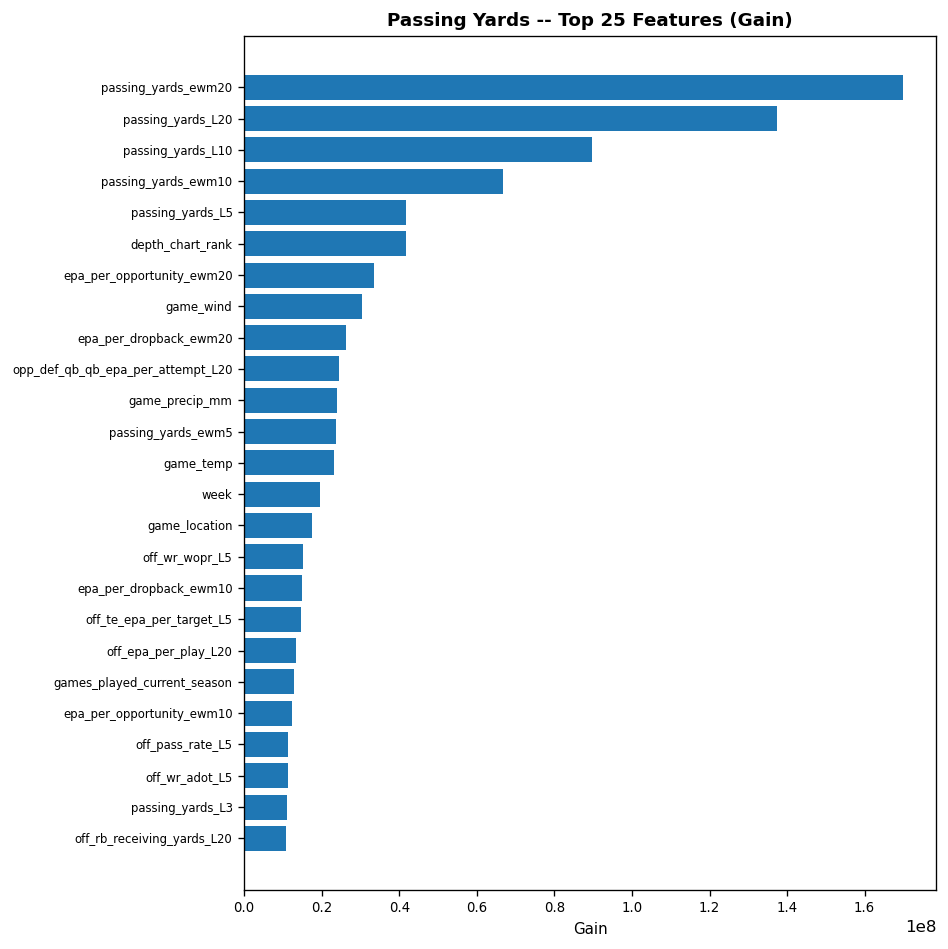


  Gain chart saved: phase7_gain_passing_yards.png
  Top 10 features (gain):
    passing_yards_ewm20                  170,020,499
    passing_yards_L20                    137,394,406
    passing_yards_L10                    89,797,646
    passing_yards_ewm10                  66,706,727
    passing_yards_L5                     41,815,340
    depth_chart_rank                     41,645,170
    epa_per_opportunity_ewm20            33,427,552
    game_wind                            30,416,429
    epa_per_dropback_ewm20               26,301,984
    opp_def_qb_qb_epa_per_attempt_L20    24,409,767


In [465]:
# --- 7.1  Native gain importance ---

imp_gain = pd.Series(
    booster.feature_importance(importance_type="gain"),
    index=FEATURE_COLS,
).sort_values(ascending=False)

top25 = imp_gain.head(25)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top25.index[::-1], top25.values[::-1], color="#1f77b4")
ax.set_title(f"{tgt.replace('_', ' ').title()} -- Top 25 Features (Gain)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Gain", fontsize=9)
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
fig_path = FIG_DIR / f"phase7_gain_{tgt}.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"\n  Gain chart saved: {fig_path.name}")
print(f"  Top 10 features (gain):")
for feat, val in imp_gain.head(10).items():
    print(f"    {feat:<35}  {val:,.0f}")


  Computing SHAP on 500 test samples...
  Top 10 features (mean |SHAP|):
    passing_yards_L20                    4.8641
    passing_yards_ewm20                  4.7093
    depth_chart_rank                     3.3048
    passing_yards_L10                    3.0856
    game_wind                            2.4513
    opp_def_qb_qb_epa_per_attempt_L20    2.3268
    passing_yards_ewm10                  2.1944
    week                                 2.1584
    game_location                        1.7755
    epa_per_opportunity_ewm20            1.7430


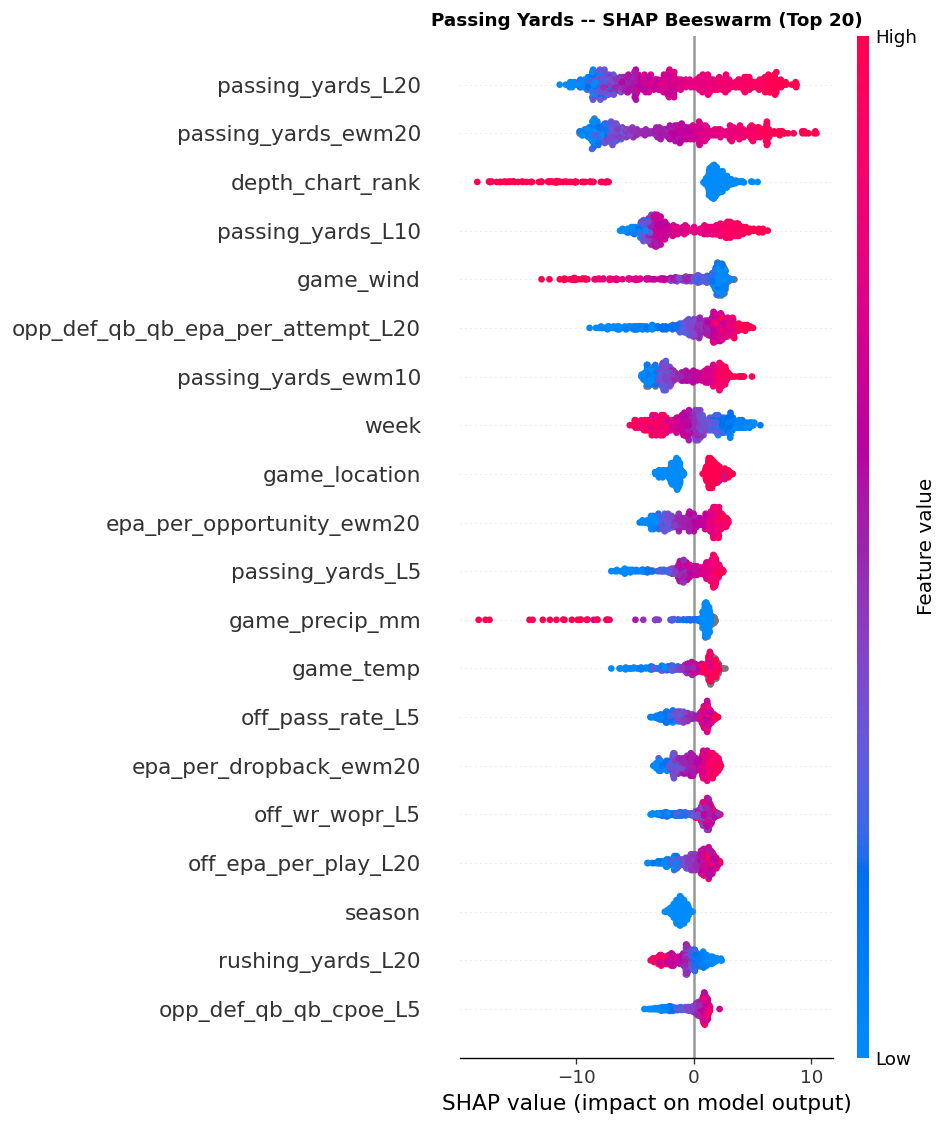


  Beeswarm saved: phase7_shap_beeswarm_passing_yards.png


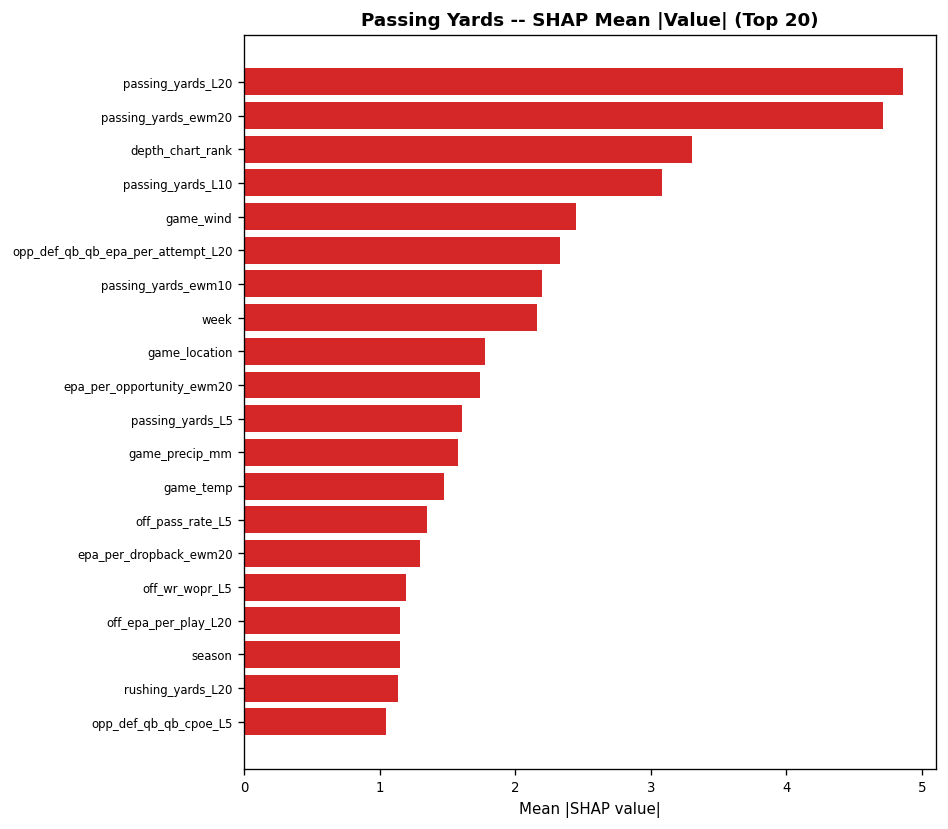

  Bar chart saved: phase7_shap_bar_passing_yards.png


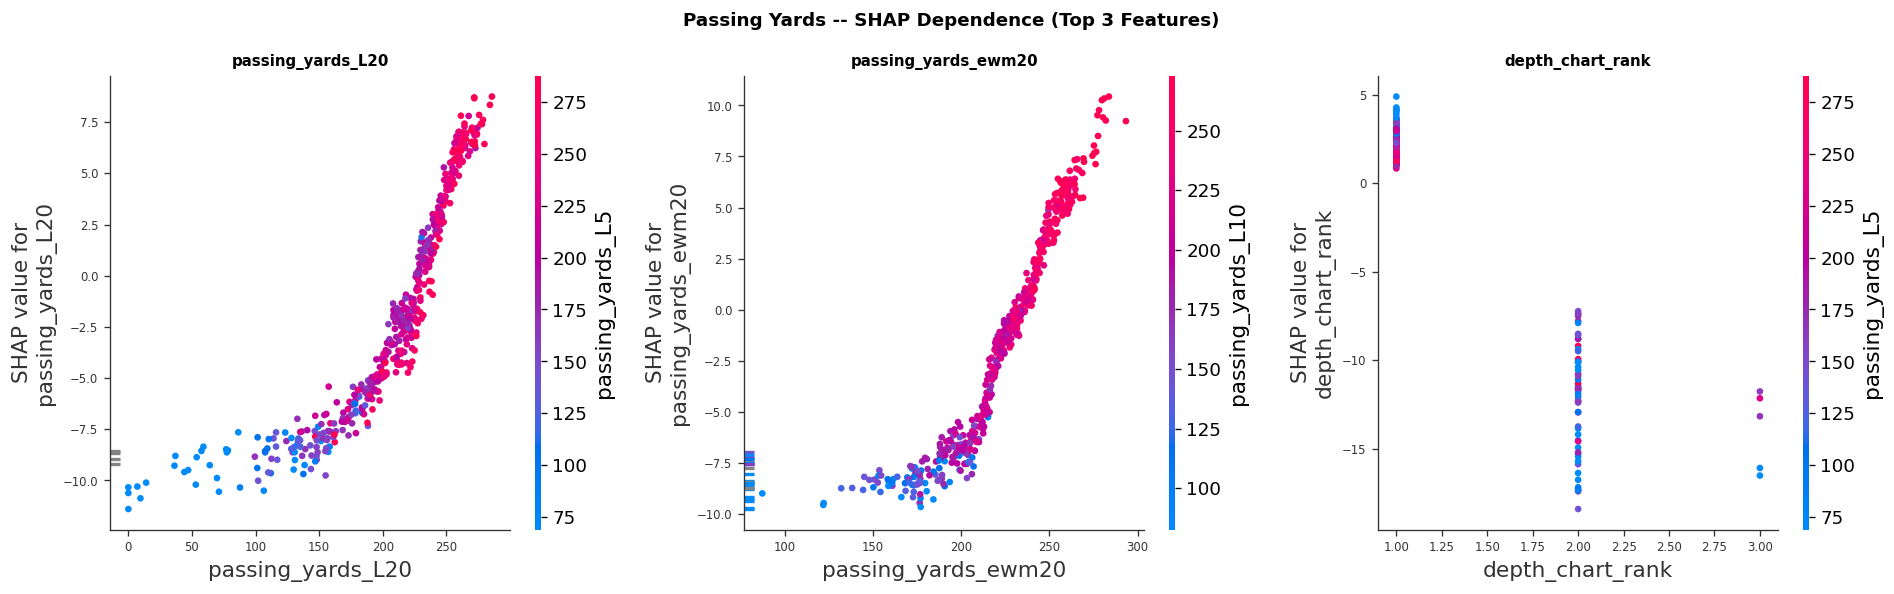

  Dependence plots saved: phase7_shap_dependence_passing_yards.png


In [466]:
# --- 7.2  SHAP ---

print(f"\n  Computing SHAP on {len(X_shap)} test samples...")
explainer = shap.TreeExplainer(booster)
shap_vals = explainer.shap_values(X_shap)

mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)

print(f"  Top 10 features (mean |SHAP|):")
for feat, val in mean_abs_shap.head(10).items():
    print(f"    {feat:<35}  {val:.4f}")

# Beeswarm
fig, ax = plt.subplots(figsize=(9, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  max_display=20, show=False, plot_type="dot")
plt.title(f"{tgt.replace('_', ' ').title()} -- SHAP Beeswarm (Top 20)",
          fontsize=11, fontweight="bold")
plt.tight_layout()
fig_path = FIG_DIR / f"phase7_shap_beeswarm_{tgt}.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"\n  Beeswarm saved: {fig_path.name}")

# Bar
top20 = mean_abs_shap.head(20)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color="#d62728")
ax.set_title(f"{tgt.replace('_', ' ').title()} -- SHAP Mean |Value| (Top 20)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Mean |SHAP value|", fontsize=9)
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
fig_path = FIG_DIR / f"phase7_shap_bar_{tgt}.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"  Bar chart saved: {fig_path.name}")

# Dependence plots -- top 3 features
top3 = list(mean_abs_shap.head(3).index)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_vals, X_shap, feature_names=FEATURE_COLS,
                         ax=ax, show=False)
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
fig.suptitle(f"{tgt.replace('_', ' ').title()} -- SHAP Dependence (Top 3 Features)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
fig_path = FIG_DIR / f"phase7_shap_dependence_{tgt}.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.close()
_show(fig_path)
print(f"  Dependence plots saved: {fig_path.name}")

In [467]:
# --- 7.3  Save SHAP artifacts ---

shap_path = ARTIFACTS_DIR / "qb_shap_values.pkl"
if shap_path.exists():
    shap_reg = joblib.load(shap_path)
else:
    shap_reg = {"shap_values": {}, "X_shap_per_target": {}, "feature_cols": FEATURE_COLS, "targets": TARGETS}

shap_reg["shap_values"][tgt]       = shap_vals
shap_reg["X_shap_per_target"][tgt] = X_shap
joblib.dump(shap_reg, shap_path)
print(f"\n  SHAP registry saved: {shap_path.name}")


  SHAP registry saved: qb_shap_values.pkl


In [468]:
# --- 7.4  Full feature tables (all features, printed + saved to Excel) ---

_full_gain = imp_gain.reset_index()
_full_gain.columns = ["feature", "gain"]
_full_gain["gain_rank"] = range(1, len(_full_gain) + 1)

_full_shap = mean_abs_shap.reset_index()
_full_shap.columns = ["feature", "mean_abs_shap"]
_full_shap["shap_rank"] = range(1, len(_full_shap) + 1)

_full_importance = _full_gain.merge(_full_shap, on="feature")
_full_importance = _full_importance[["gain_rank", "shap_rank", "feature", "gain", "mean_abs_shap"]]

print(f"\n  ALL FEATURES — Gain and SHAP ({len(_full_importance)} total):")
print(f"  {'Rank(G)':>8}  {'Rank(S)':>8}  {'Feature':<45}  {'Gain':>15}  {'Mean|SHAP|':>12}")
print("  " + "-"*95)
for _, row in _full_importance.iterrows():
    print(f"  {int(row.gain_rank):>8}  {int(row.shap_rank):>8}  {row.feature:<45}  {row.gain:>15,.0f}  {row.mean_abs_shap:>12.4f}")

_imp_path = DATA_DIR / f"feature_importance_{tgt}.xlsx"
_full_importance.to_excel(_imp_path, index=False)
print(f"\n  Full importance table saved: {_imp_path.name}")

print(f"\nPhase 7 complete for [{tgt}].")
print(f"  Figures saved to {FIG_DIR}")
print(f"\n  --> Next target: change ACTIVE_TARGET at the top of Phase 5 and re-run phases 5-7.")


  ALL FEATURES — Gain and SHAP (86 total):
   Rank(G)   Rank(S)  Feature                                                   Gain    Mean|SHAP|
  -----------------------------------------------------------------------------------------------
         1         2  passing_yards_ewm20                                170,020,499        4.7093
         2         1  passing_yards_L20                                  137,394,406        4.8641
         3         4  passing_yards_L10                                   89,797,646        3.0856
         4         7  passing_yards_ewm10                                 66,706,727        2.1944
         5        11  passing_yards_L5                                    41,815,340        1.6088
         6         3  depth_chart_rank                                    41,645,170        3.3048
         7        10  epa_per_opportunity_ewm20                           33,427,552        1.7430
         8         5  game_wind                                   

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\franc\\OneDrive\\Jupyter\\Business\\NFL\\feature_importance_passing_yards.xlsx'

In [ ]:
# =============================================================================
# PHASE 7B  --  SEASON-LEVEL FIT DIAGNOSTICS: passing_yards
# =============================================================================
# Aggregate per-game predictions to season totals per QB, then evaluate.
# This is the relevant view for season-long fantasy projections.
# =============================================================================

print("\n" + "="*60)
print(f"PHASE 7B  --  SEASON-LEVEL DIAGNOSTICS: {tgt}")
print("="*60)

# Load the per-game test predictions written in Phase 6.6
_pred_path = DATA_DIR / f"test_predictions_2025_{tgt}.xlsx"
_pg = pd.read_excel(_pred_path)

# Aggregate to season totals per QB
_szn = (
    _pg.groupby("player_display_name")
    .agg(
        games          =("actual_passing_yards",    "count"),
        actual_total   =("actual_passing_yards",    "sum"),
        predicted_total=("predicted_passing_yards", "sum"),
        depth_chart_rank_min=("depth_chart_rank",   "min"),
    )
    .reset_index()
    .sort_values("actual_total", ascending=False)
)
_szn["residual"]     = _szn["predicted_total"] - _szn["actual_total"]
_szn["abs_residual"] = _szn["residual"].abs()
_szn["pct_error"]    = (_szn["residual"] / _szn["actual_total"].replace(0, np.nan)).abs()

# Fit diagnostics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

_act  = _szn["actual_total"].values
_pred = _szn["predicted_total"].values

_mae  = mean_absolute_error(_act, _pred)
_rmse = np.sqrt(mean_squared_error(_act, _pred))
_r2   = r2_score(_act, _pred)
_bias = (_pred - _act).mean()
_mape = _szn["pct_error"].mean() * 100
_r    = np.corrcoef(_act, _pred)[0, 1]
_within10 = (_szn["pct_error"] <= 0.10).mean() * 100
_within20 = (_szn["pct_error"] <= 0.20).mean() * 100

print(f"\n  Season-level totals: {len(_szn)} QBs  ({_szn['games'].sum()} total game-rows)")
print(f"\n  {'Metric':<20}  {'Value':>10}")
print(f"  {'-'*32}")
print(f"  {'MAE (yards)':<20}  {_mae:>10.1f}")
print(f"  {'RMSE (yards)':<20}  {_rmse:>10.1f}")
print(f"  {'R2':<20}  {_r2:>10.4f}")
print(f"  {'Bias (pred-act)':<20}  {_bias:>10.1f}")
print(f"  {'MAPE':<20}  {_mape:>10.2f}%")
print(f"  {'Pearson r':<20}  {_r:>10.4f}")
print(f"  {'Within 10%':<20}  {_within10:>10.1f}%")
print(f"  {'Within 20%':<20}  {_within20:>10.1f}%")

print(f"\n  {'QB':<25}  {'G':>3}  {'Actual':>8}  {'Pred':>8}  {'Resid':>8}  {'Pct Err':>8}  {'DC Rank':>7}")
print(f"  {'-'*75}")
for _, row in _szn.iterrows():
    print(f"  {row.player_display_name:<25}  {int(row.games):>3}  {row.actual_total:>8.0f}  "
          f"{row.predicted_total:>8.0f}  {row.residual:>+8.0f}  {row.pct_error*100:>7.1f}%  {int(row.depth_chart_rank_min):>7}")

# Save season-level summary to Excel
_szn_path = DATA_DIR / f"test_predictions_2025_{tgt}_season_totals.xlsx"
_szn.to_excel(_szn_path, index=False)
print(f"\n  Season totals saved: {_szn_path.name}")